## Project Summary -
   This project aims to improve Customer Satisfaction (CSAT) by using Machine Learning techniques on customer support data. I performed data cleaning and Exploratory Data Analysis (EDA) to identify key factors affecting customer experience. To handle class imbalance, SMOTE was applied, and a Random Forest Classifier was trained to predict CSAT scores effectively.

# Business Context -
  In the highly competitive e-commerce sector, Customer Satisfaction (CSAT) is a key performance metric for Flipkart. This project analyzes customer support interactions to identify key drivers of satisfaction and dissatisfaction. It also helps in predicting CSAT scores to proactively identify at-risk customers and improve overall support experience.

# Problem Statement -
 Customer support teams often work reactively, identifying unhappy customers only after negative feedback or churn. Manually analyzing large volumes of support data is inefficient, and class imbalance makes it difficult for models to detect low CSAT cases. This project solves this by building a machine learning model to predict CSAT scores and using GenAI to summarize customer complaints for faster insights.

# Project Pipeline -

  Data Cleaning & EDA: Handled missing values, outliers, and explored data patterns

  Feature Engineering: Created response-time features and encoded categorical variables

  Modeling: Trained models like Logistic Regression and Random Forest with imbalance handling

### ***1. Know Your Data***

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Load Dataset 
df = pd.read_csv("../data/Customer_support_data.csv")


In [18]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [19]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

In [20]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

In [21]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

In [22]:
# Missing Values/Null Values Count
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

In [23]:
#Statistical Summary of Numerical Columns
print("Numerical Summary")
display(df.describe())

Numerical Summary


,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


# 2 **Data cleaning**

In [26]:
# 1. Date Conversion (with format)
date_cols = ['order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors='coerce')


# 2. Missing Values Handling

# Item_price → median
price_median = df['Item_price'].median()
df['Item_price'] = df['Item_price'].fillna(price_median)

# Agent Shift → mode
shift_mode = df['Agent Shift'].mode()[0]
df['Agent Shift'] = df['Agent Shift'].fillna(shift_mode)

# Customer Remarks → No Remarks
df['Customer Remarks'] = df['Customer Remarks'].fillna("No Remarks")

# Drop missing target
df = df.dropna(subset=['CSAT Score'])


# 3. Verification
print(df.isnull().sum())

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks               0
Order_id                   18232
order_date_time            68693
Issue_reported at          53933
issue_responded            54022
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                     0
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


Text(0, 0.5, 'Count')

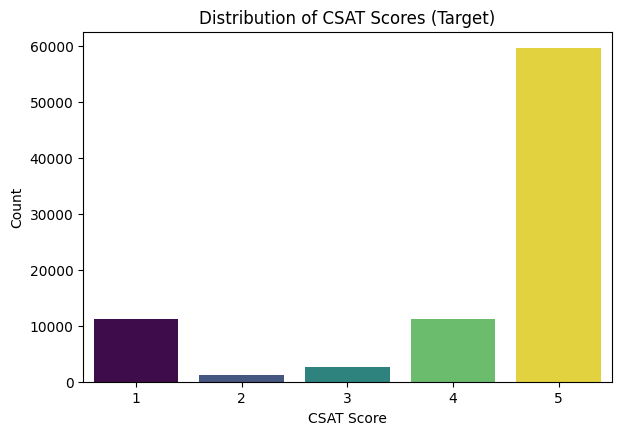

In [49]:
# EXPLORATORY DATA ANALYSIS (EDA)

plt.figure(figsize=(15, 10))

# 1. Target Variable Distribution (CSAT Score)
plt.subplot(2, 2, 1)

sns.countplot(
    x='CSAT Score',
    hue='CSAT Score',   # ✅ fix
    data=df,
    palette='viridis',
    legend=False        # ✅ legend remove
)

plt.title('Distribution of CSAT Scores (Target)')
plt.xlabel('CSAT Score')
plt.ylabel('Count')

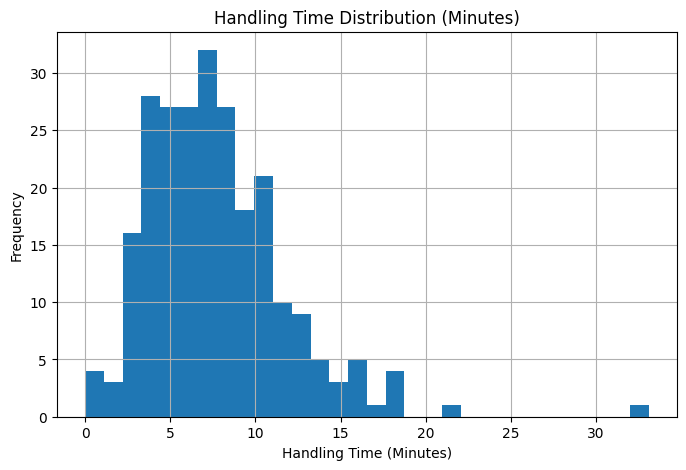

In [51]:
import matplotlib.pyplot as plt

# 1. Convert seconds → minutes
df["handling_time_min"] = df["connected_handling_time"] / 60

# 2. Plot Histogram (Minutes me)
plt.figure(figsize=(8,5))

df["handling_time_min"].dropna().hist(bins=30)

plt.title("Handling Time Distribution (Minutes)")
plt.xlabel("Handling Time (Minutes)")   # ✅ clear axis
plt.ylabel("Frequency")

plt.show()

<Figure size 640x480 with 0 Axes>

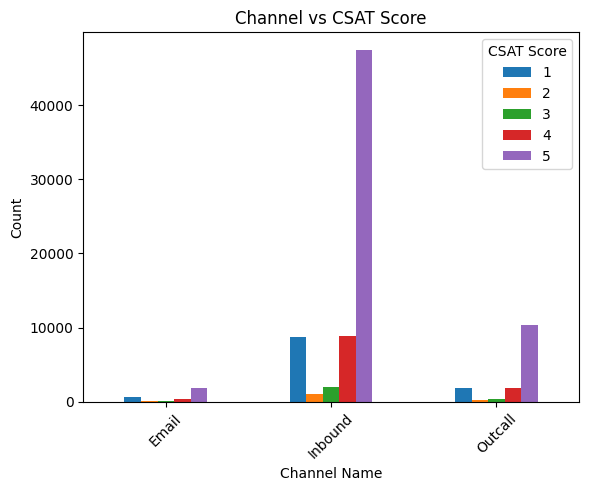

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# Crosstab
channel_csat = pd.crosstab(df["channel_name"], df["CSAT Score"])

# Bar Plot
plt.figure()
channel_csat.plot(kind="bar")

plt.title("Channel vs CSAT Score")
plt.xlabel("Channel Name")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

# . Feature Engineering & Outlier Removal

Outliers removed. Capped handling time at 1108.85 minutes.


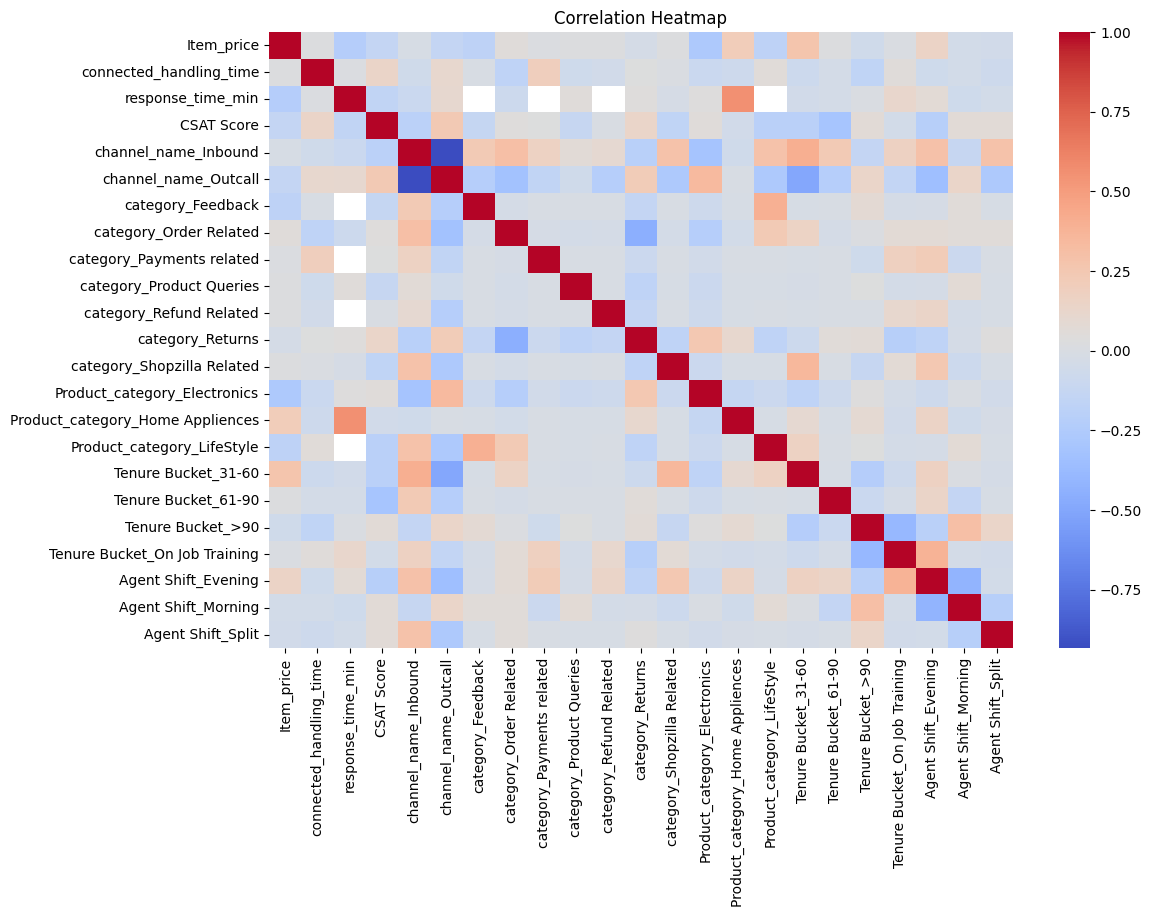

Final Dataset Shape for Modeling: (239, 23)


In [45]:
# 1. Handle Outliers (Capping at 99th percentile)
upper_limit = df['connected_handling_time'].quantile(0.99)
df_clean = df[df['connected_handling_time'] <= upper_limit].copy()
print(f"Outliers removed. Capped handling time at {upper_limit:.2f} minutes.")

# 2. Feature Creation: Response Time (in Minutes)
# Formula: (Responded Time - Reported Time) converted to minutes
df_clean['response_time_min'] = (df_clean['issue_responded'] - df_clean['Issue_reported at']).dt.total_seconds() / 60

# 3. Select Columns for Modeling
# We drop IDs, Dates (since we extracted info), and Names
features_to_keep = [
    'channel_name', 'category', 'Product_category',
    'Item_price', 'connected_handling_time', 'response_time_min',
    'Tenure Bucket', 'Agent Shift', 'CSAT Score'
]

df_model = df_clean[features_to_keep].copy()

# 4. Encode Categorical Variables (One-Hot Encoding)
# This turns text like "Morning", "Evening" into numbers 0 and 1
df_final = pd.get_dummies(df_model, drop_first=True)

# 5. Check Correlation (Multicollinearity)
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

print(f"Final Dataset Shape for Modeling: {df_final.shape}")
     

# . Model Training (The "Brain" of the Project)

Applying SMOTE... (Setting k_neighbors=1 for rare classes)
✅ SMOTE Complete!
Original Training Count: 191
Resampled Training Count: 725 (Balanced!)

Training Random Forest Classifier...

--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.25      0.14      0.18         7
           5       0.73      0.75      0.74        36

    accuracy                           0.58        48
   macro avg       0.20      0.18      0.18        48
weighted avg       0.58      0.58      0.58        48



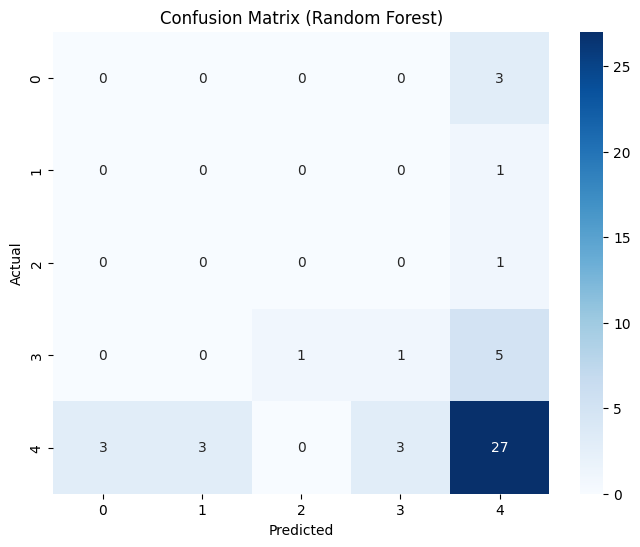

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# 1. Final Clean-up
# Fill any NaNs created during feature engineering with 0
df_final.fillna(0, inplace=True)

# 2. Split Data into X (Features) and y (Target)
X = df_final.drop('CSAT Score', axis=1)
y = df_final['CSAT Score']

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Handle Imbalance using SMOTE (With k_neighbors fix)
print("Applying SMOTE... (Setting k_neighbors=1 for rare classes)")

# k_neighbors=1 ensures it works even if a class has only 2 or 3 samples
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"✅ SMOTE Complete!")
print(f"Original Training Count: {y_train.shape[0]}")
print(f"Resampled Training Count: {y_train_smote.shape[0]} (Balanced!)")

# 5. Train Model: Random Forest
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# 6. Evaluate
y_pred = rf_model.predict(X_test)

print("\n--- Random Forest Evaluation ---")
print(classification_report(y_test, y_pred))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# . Feature Importance

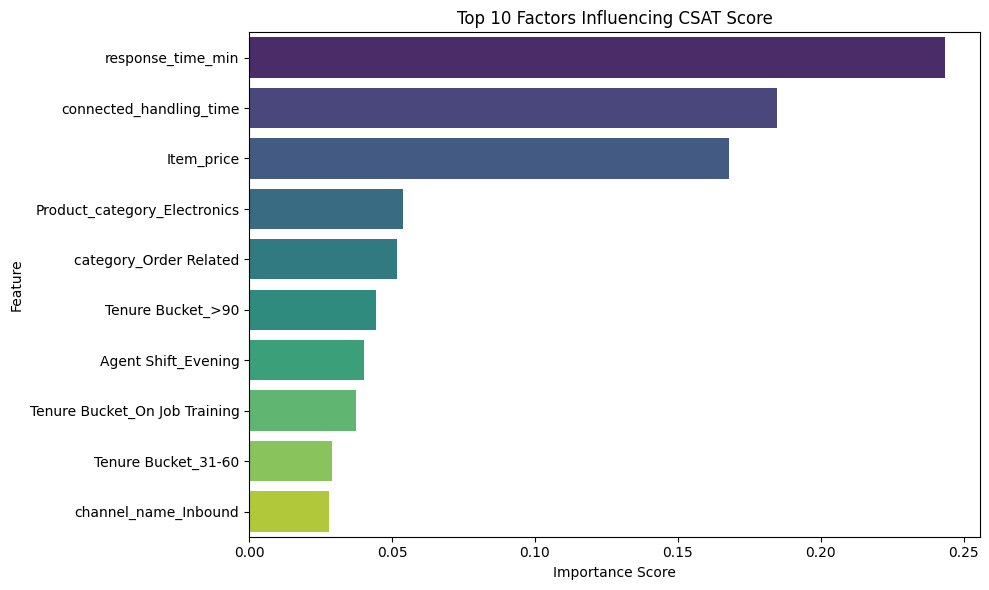


📊 Key Business Insight:
👉 The most important factor affecting Customer Satisfaction is: response_time_min

💡 Recommendation:
Focus on optimizing 'response_time_min' to improve overall CSAT scores.
This feature has the highest impact on customer experience.


In [48]:
# ==============================
# 1. Extract Feature Importances
# ==============================
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# ==============================
# 2. Sort Top 10 Features
# ==============================
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
).head(10)

# ==============================
# 3. Visualization (Clean & No Warning)
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',          # ✅ fix for warning
    data=feature_importance_df,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Factors Influencing CSAT Score')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

# ==============================
# 4. Business Insight
# ==============================
top_feature = feature_importance_df.iloc[0]['Feature']

print("\n📊 Key Business Insight:")
print(f"👉 The most important factor affecting Customer Satisfaction is: {top_feature}")

print("\n💡 Recommendation:")
print(f"Focus on optimizing '{top_feature}' to improve overall CSAT scores.")
print("This feature has the highest impact on customer experience.")